In [1]:
import sys
module_path = '/home/cpanourg/projects/2-hdvc/'
if module_path not in sys.path:
    sys.path.append(module_path)
from src.utils import (
    read_fvecs, compute_distance_tables_threaded, compute_distance_tables_vectorized,
    adc_distances_batch_numba, read_fbin, load_dataset, ensure_dir, divisors
)


In [2]:
dataset_name = 'glove'
dim = {'gist': 960, 'deep': 96, 'glove': 200}
train_size = {'gist': 500_000, 'deep': 100_000_000, 'glove': 1_000_000}
train_path = {'gist': '/mnthdd/cpanourg/2-hdvc/data/gist/gist_learn.fvecs', 'deep': '/mnthdd/cpanourg/2-hdvc/data/deep1b/dataset/learn_100m.bin', 'glove': '/mnthdd/cpanourg/2-hdvc/data/glove/splits/train.bin'}
dataset_pdf_path = {'gist': '/mnthdd/cpanourg/2-hdvc/data/gist/gist_profile.pdf', 'deep': '/mnthdd/cpanourg/2-hdvc/data/deep1b/deep1b_profile.pdf', 'glove': '/mnthdd/cpanourg/2-hdvc/data/glove/glove_profile.pdf'}


X, _ = load_dataset(train_path[dataset_name], None, dim[dataset_name], db_chunk_size=train_size[dataset_name] + 10_000, qr_chunk_size=None)
print(X.shape)

(1000000, 200)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Set standard serif font
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times", "Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

N, D = X.shape
print(f"Using X with shape: N={N}, D={D}")

# Optionally subsample for speed
max_samples = 1_000_000
if N > max_samples:
    idx = np.random.choice(N, size=max_samples, replace=False)
    X_sub = X[idx]
    print(f"Subsampled to {X_sub.shape[0]} points for analysis")
else:
    X_sub = X

# Optionally restrict to a subset of dimensions for correlation plots
max_dims = 1000
if D > max_dims:
    dim_idx = np.random.choice(D, size=max_dims, replace=False)
    dim_idx = np.sort(dim_idx)
    X_corr = X_sub[:, dim_idx]
    print(f"Using {max_dims} dims (subset) for correlation diagnostics")
else:
    X_corr = X_sub

# Standardize per-dimension
Xc = X_corr - X_corr.mean(axis=0, keepdims=True)
std = Xc.std(axis=0, keepdims=True) + 1e-8
Xc /= std

# === Compute all data first ===
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

corr = np.corrcoef(Xc, rowvar=False)
dist = 1.0 - np.abs(corr)
Z = linkage(squareform(dist, checks=False), method="average")
perm = leaves_list(Z)
corr_reordered = corr[np.ix_(perm, perm)]

tri = np.triu_indices_from(corr, k=1)
abs_r = np.abs(corr[tri])

var_per_dim = X_sub.var(axis=0)

# Candidate numbers of subquantizers M (blocks)
candidate_M = divisors(D)
D_eff = X_sub.shape[1]
block_vars_dict = {}
for M in candidate_M:
    if D_eff % M == 0:
        block_size = D_eff // M
        block_vars_dict[M] = [var_per_dim[i*block_size:(i+1)*block_size].sum() for i in range(M)]

# PCA
try:
    from sklearn.decomposition import PCA
    max_pcs = min(256, X_sub.shape[1])
    pca = PCA(n_components=max_pcs, svd_solver="randomized")
    pca.fit(X_sub)
    evr = pca.explained_variance_ratio_
    cum = np.cumsum(evr)
    pca_available = True
except ImportError:
    pca_available = False

# === Create combined figure ===
# Calculate layout: need rows for correlation (1), histogram/variance (1), block plots, and PCA
num_block_plots = len(block_vars_dict)
num_block_rows = (num_block_plots + 2) // 3  # 3 plots per row, round up
num_rows = 2 + num_block_rows + (1 if pca_available else 0)
num_cols = 3




Using X with shape: N=1000000, D=200


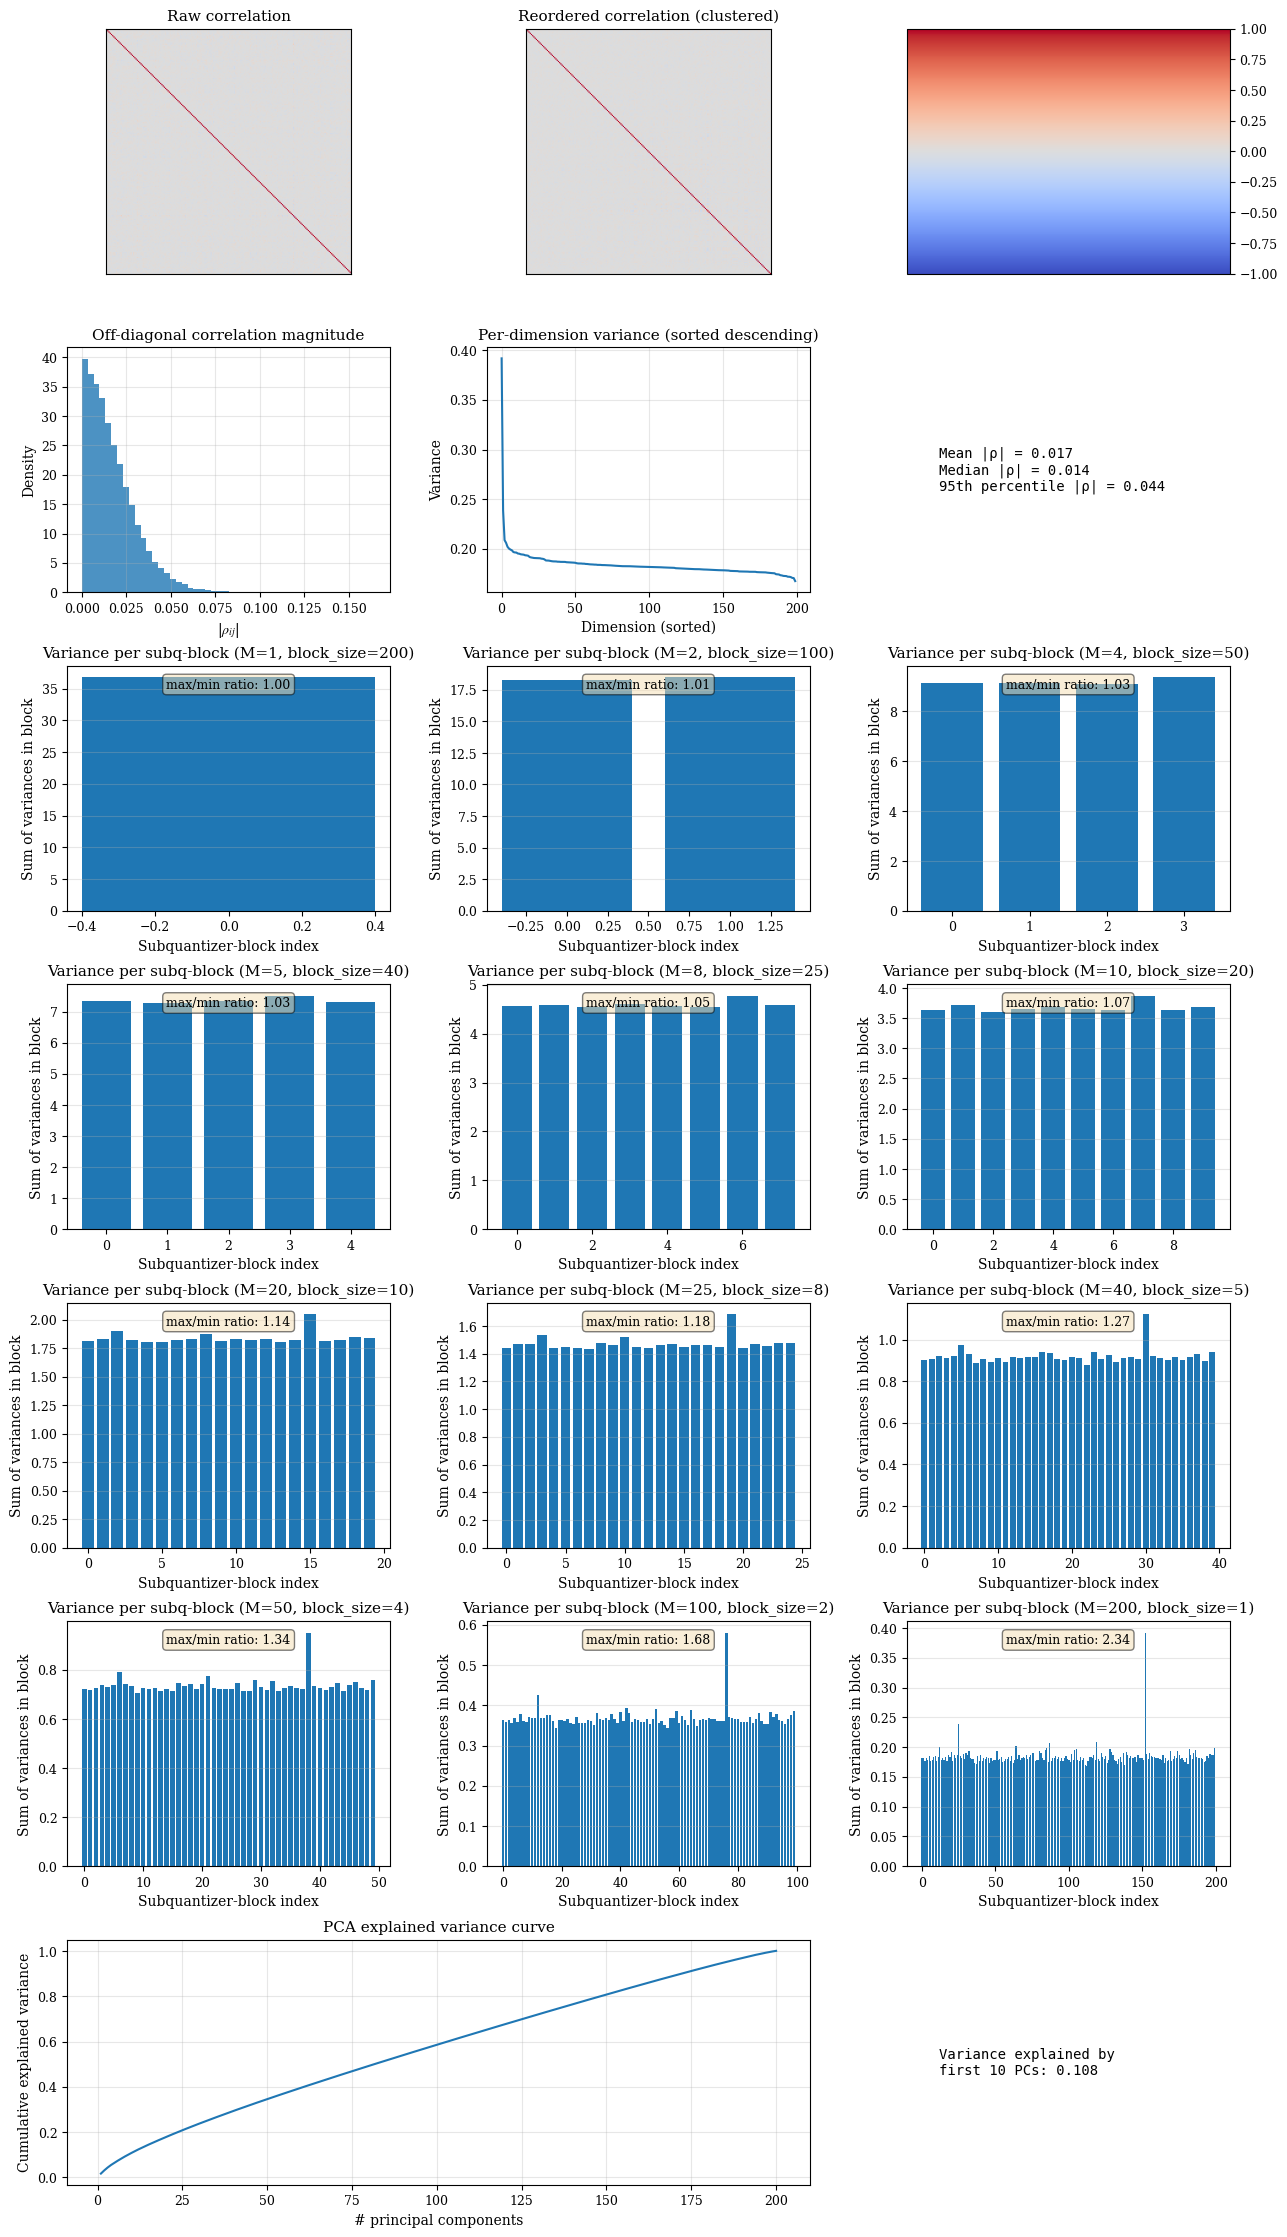


Mean |rho_ij| = 0.017
Median |rho_ij| = 0.014
95th percentile |rho_ij| = 0.044
M=1: max(block_var) / min(block_var) = 1.00
M=2: max(block_var) / min(block_var) = 1.01
M=4: max(block_var) / min(block_var) = 1.03
M=5: max(block_var) / min(block_var) = 1.03
M=8: max(block_var) / min(block_var) = 1.05
M=10: max(block_var) / min(block_var) = 1.07
M=20: max(block_var) / min(block_var) = 1.14
M=25: max(block_var) / min(block_var) = 1.18
M=40: max(block_var) / min(block_var) = 1.27
M=50: max(block_var) / min(block_var) = 1.34
M=100: max(block_var) / min(block_var) = 1.68
M=200: max(block_var) / min(block_var) = 2.34
Variance explained by first 10 PCs: 0.108


In [6]:

fig = plt.figure(figsize=(15, 4 * num_rows))
gs = fig.add_gridspec(num_rows, num_cols, hspace=0.3, wspace=0.3)

# Row 1: Correlation heatmaps
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax1.set_title("Raw correlation")
ax1.set_xticks([])
ax1.set_yticks([])

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(corr_reordered, vmin=-1, vmax=1, cmap="coolwarm")
ax2.set_title("Reordered correlation (clustered)")
ax2.set_xticks([])
ax2.set_yticks([])

# Colorbar for heatmaps
cbar_ax = fig.add_subplot(gs[0, 2])
fig.colorbar(im2, cax=cbar_ax)

# Row 2: Histogram and variance plot
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(abs_r, bins=50, density=True, alpha=0.8)
ax3.set_xlabel(r"|$\rho_{ij}$|")
ax3.set_ylabel("Density")
ax3.set_title("Off-diagonal correlation magnitude")
ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(np.sort(var_per_dim)[::-1])
ax4.set_xlabel("Dimension (sorted)")
ax4.set_ylabel("Variance")
ax4.set_title("Per-dimension variance (sorted descending)")
ax4.grid(alpha=0.3)

# Row 2, col 3: Print stats
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
stats_text = f"Mean |ρ| = {abs_r.mean():.3f}\n"
stats_text += f"Median |ρ| = {np.median(abs_r):.3f}\n"
stats_text += f"95th percentile |ρ| = {np.percentile(abs_r, 95):.3f}"
ax5.text(0.1, 0.5, stats_text, fontsize=10, verticalalignment='center', family='monospace')

# Block variance plots
row_idx = 2
block_plot_idx = 0
for M in candidate_M:
    if M not in block_vars_dict:
        continue
    col_idx = block_plot_idx % 3
    if block_plot_idx > 0 and block_plot_idx % 3 == 0:
        row_idx += 1
    ax = fig.add_subplot(gs[row_idx, col_idx])
    block_vars = block_vars_dict[M]
    block_size = D_eff // M
    ax.bar(range(M), block_vars)
    ax.set_xlabel("Subquantizer-block index")
    ax.set_ylabel("Sum of variances in block")
    ax.set_title(f"Variance per subq-block (M={M}, block_size={block_size})")
    ax.grid(axis="y", alpha=0.3)
    ratio = max(block_vars) / max(1e-12, min(block_vars))
    ax.text(0.5, 0.95, f"max/min ratio: {ratio:.2f}", 
            transform=ax.transAxes, ha='center', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    block_plot_idx += 1

# PCA plot if available
if pca_available:
    row_idx += 1
    ax_pca = fig.add_subplot(gs[row_idx, :2])
    ax_pca.plot(range(1, max_pcs + 1), cum)
    ax_pca.set_xlabel("# principal components")
    ax_pca.set_ylabel("Cumulative explained variance")
    # ax_pca.set_ylim(0, 2.01)
    ax_pca.grid(alpha=0.3)
    ax_pca.set_title("PCA explained variance curve")
    
    ax_pca_stats = fig.add_subplot(gs[row_idx, 2])
    ax_pca_stats.axis('off')
    pca_text = f"Variance explained by\nfirst 10 PCs: {cum[min(9, max_pcs-1)]:.3f}"
    ax_pca_stats.text(0.1, 0.5, pca_text, fontsize=10, verticalalignment='center', family='monospace')

folder_postfix = '1b' if dataset_name == 'deep' else ''
plt.savefig(dataset_pdf_path[dataset_name], bbox_inches='tight')
plt.show()

# Print statisticsz
print(f"\nMean |rho_ij| = {abs_r.mean():.3f}")
print(f"Median |rho_ij| = {np.median(abs_r):.3f}")
print(f"95th percentile |rho_ij| = {np.percentile(abs_r, 95):.3f}")

for M in candidate_M:
    if M in block_vars_dict:
        block_vars = block_vars_dict[M]
        ratio = max(block_vars) / max(1e-12, min(block_vars))
        print(f"M={M}: max(block_var) / min(block_var) = {ratio:.2f}")

if pca_available:
    print(f"Variance explained by first 10 PCs: {cum[min(9, max_pcs-1)]:.3f}")